# rust-NMF vs R `NMF` on omicverse PBMC 8k

Real single-cell benchmark on the omicverse-bundled `pbmc8k.h5ad`
(7750 cells × 20939 genes, 10x Genomics).

Pipeline:
1. Load + log-normalise + take top-`HVG_N` HVGs.
2. Generate `W0`/`H0` in **R** so both backends use literally the
   same starting point.
3. Run `NMF::nmf(method='brunet')` and `nmf_rs.nmf('brunet')` for
   `MAXIT` iterations. Same for `lee`.
4. Compare bitwise / column-wise Pearson, plot wall-clock.

In [1]:
import os, sys, time, subprocess, shutil
from pathlib import Path
import numpy as np, pandas as pd
import scanpy as sc, anndata as ad
import matplotlib.pyplot as plt
import nmf_rs

PBMC = '/scratch/users/steorra/analysis/omicverse_dev/omicverse/data/pbmc8k.h5ad'
WORK = Path('pbmc_bench'); WORK.mkdir(exist_ok=True)
RSCRIPT = '/scratch/users/steorra/env/CMAP/bin/Rscript'
RLIB    = '/scratch/users/steorra/env/CMAP_Rlib'
PATH_R  = '/scratch/users/steorra/env/CMAP/bin'
HVG_N, RANK, MAXIT = 2000, 10, 100
print('omicverse pbmc8k:', PBMC, 'exists:', Path(PBMC).exists())

omicverse pbmc8k: /scratch/users/steorra/analysis/omicverse_dev/omicverse/data/pbmc8k.h5ad exists: True


## 1. Load and preprocess

Standard scanpy log-normalisation, then top-`HVG_N` HVGs by Seurat
v3 dispersion. Result is `V` of shape (genes × cells), dense float64.

In [2]:
ad_orig = ad.read_h5ad(PBMC)
print('raw:', ad_orig.shape, 'X dtype:', ad_orig.X.dtype)
ad_orig.layers['counts'] = ad_orig.X.copy()
sc.pp.normalize_total(ad_orig, target_sum=1e4)
sc.pp.log1p(ad_orig)
sc.pp.highly_variable_genes(ad_orig, n_top_genes=HVG_N, flavor='seurat_v3', layer='counts')
ad_hvg = ad_orig[:, ad_orig.var.highly_variable].copy()
V = np.ascontiguousarray(ad_hvg.X.toarray().T.astype(np.float64))  # (genes × cells)
print('V shape (genes × cells):', V.shape, 'min/max:', V.min(), V.max())
n_genes, n_cells = V.shape
np.savetxt(WORK/'V.tsv', V, delimiter='\t')

raw: (7750, 20939) X dtype: float32


V shape (genes × cells): (2000, 7750) min/max: 0.0 8.51203441619873


## 2. Seed W0/H0 in R

R's `runif()` Mersenne Twister stream isn't directly accessible from
Python. To enable a strict bit-parity comparison, we generate the
initial factors in R and pickle them as TSV.

In [3]:
rscript = f'''
set.seed(2024L)
V <- as.matrix(read.table("{WORK}/V.tsv", sep="\\t"))
W0 <- matrix(runif({n_genes}*{RANK}, 0, max(V)), {n_genes}, {RANK})
H0 <- matrix(runif({RANK}*{n_cells}, 0, max(V)), {RANK}, {n_cells})
write.table(W0, "{WORK}/W0.tsv", sep="\\t", row.names=FALSE, col.names=FALSE)
write.table(H0, "{WORK}/H0.tsv", sep="\\t", row.names=FALSE, col.names=FALSE)
cat("seed_done\\n")
'''
(WORK/'seed.R').write_text(rscript)
out = subprocess.run([RSCRIPT, str(WORK/'seed.R')], capture_output=True, text=True,
                      env={**os.environ, 'PATH': PATH_R + ':' + os.environ.get('PATH','')})
print(out.stdout); print(out.stderr[-200:] if out.stderr else '')
W0 = np.loadtxt(WORK/'W0.tsv'); H0 = np.loadtxt(WORK/'H0.tsv')
W0.shape, H0.shape

seed_done




((2000, 10), (10, 7750))

## 3. Run R `NMF::nmf(brunet)` and `lee`

In [4]:
rscript = f'''
suppressPackageStartupMessages({{
  .libPaths(c("{RLIB}", .libPaths()))
  library(NMF)
}})
args <- commandArgs(trailingOnly=TRUE); method <- args[1]
V  <- as.matrix(read.table("{WORK}/V.tsv",  sep="\\t"))
W0 <- as.matrix(read.table("{WORK}/W0.tsv", sep="\\t"))
H0 <- as.matrix(read.table("{WORK}/H0.tsv", sep="\\t"))
.seed <- function(model, target, ...) {{ basis(model)<-W0; coef(model)<-H0; model }}
t0 <- proc.time()[3]
fit <- nmf(V, rank=ncol(W0), method=method, seed=.seed,
           .options="-cb", .pbackend=NA, nrun=1, maxIter={MAXIT},
           stopconv=10L*{MAXIT})
cat(sprintf("R_TIME %s %.4f\\n", method, proc.time()[3] - t0))
write.table(basis(fit), sprintf("{WORK}/%s__W_R.tsv", method), sep="\\t",
            row.names=FALSE, col.names=FALSE)
write.table(coef(fit),  sprintf("{WORK}/%s__H_R.tsv", method), sep="\\t",
            row.names=FALSE, col.names=FALSE)
'''
(WORK/'run.R').write_text(rscript)
r_times = {}
for method in ('brunet', 'lee'):
    out = subprocess.run([RSCRIPT, str(WORK/'run.R'), method], capture_output=True, text=True,
                         env={**os.environ, 'PATH': PATH_R + ':' + os.environ.get('PATH','')})
    print(out.stdout.splitlines()[-1])
    for line in out.stdout.splitlines():
        if line.startswith('R_TIME'):
            _, m, t = line.split(); r_times[m] = float(t)
r_times

R_TIME brunet 78.7430


R_TIME lee 125.2120


{'brunet': 78.743, 'lee': 125.212}

## 4. Run nmf-rs at several thread counts

Each call passes `num_threads=N`, which builds a fresh rayon pool
scoped to that single call — so different threading configurations
can coexist in one process (unlike `set_num_threads`, which is a
one-shot global init).

In [5]:
THREADS = (1, 2, 4, 8, 16)
rs_times = {nt: {} for nt in THREADS}
for nt in THREADS:
    for method in ('brunet', 'lee'):
        t = time.perf_counter()
        res = nmf_rs.nmf(V, rank=RANK, method=method, W0=W0.copy(), H0=H0.copy(),
                         max_iter=MAXIT, stop='max_iter', num_threads=nt)
        rs_times[nt][method] = time.perf_counter() - t
        if nt == max(THREADS):
            np.savetxt(WORK/f'{method}__W_rs.tsv', res.W, delimiter='\t')
            np.savetxt(WORK/f'{method}__H_rs.tsv', res.H, delimiter='\t')
        print(f'{method:6s} {nt}t: {rs_times[nt][method]:.2f} s')
rs_times

brunet 1t: 54.69 s


lee    1t: 19.35 s


brunet 2t: 28.89 s


lee    2t: 10.26 s


brunet 4t: 14.27 s


...

brunet 8t: 7.29 s


lee    8t: 2.71 s


brunet 16t: 4.30 s


lee    16t: 1.65 s


{1: {'brunet': 54.69181117499829, 'lee': 19.34898688798421},
 2: {'brunet': 28.886805328016635, 'lee': 10.25944041000912},
 4: {'brunet': 14.266988071991364, 'lee': 5.106636136013549},
 8: {'brunet': 7.287552691006567, 'lee': 2.707332884980133},
 16: {'brunet': 4.304234929004451, 'lee': 1.653249498020159}}

## 5. Bit-equivalence check + correlation

Same V/W0/H0 → both backends should be bitwise identical.

In [6]:
rows = []
for method in ('brunet', 'lee'):
    W_R = np.loadtxt(WORK/f'{method}__W_R.tsv'); H_R = np.loadtxt(WORK/f'{method}__H_R.tsv')
    W_rs = np.loadtxt(WORK/f'{method}__W_rs.tsv'); H_rs = np.loadtxt(WORK/f'{method}__H_rs.tsv')
    dW = float(np.abs(W_R - W_rs).max());  dH = float(np.abs(H_R - H_rs).max())
    # Column-wise Pearson on W (factors) and on H (samples).
    rW = np.array([np.corrcoef(W_R[:,k], W_rs[:,k])[0,1] for k in range(W_R.shape[1])])
    rH = np.array([np.corrcoef(H_R[k,:], H_rs[k,:])[0,1] for k in range(H_R.shape[0])])
    rows.append({'method': method,
                 'max|ΔW|': dW, 'max|ΔH|': dH,
                 'min corr W (per factor)': float(rW.min()),
                 'min corr H (per factor)': float(rH.min()),
                 'bit-equiv': dW < 1e-9 and dH < 1e-9})
pd.DataFrame(rows)

,method,max|ΔW|,max|ΔH|,min corr W (per factor),min corr H (per factor),bit-equiv
0,brunet,1.648459e-12,6.245005e-16,1.0,1.0,True
1,lee,7.112366e-17,1.648459e-12,1.0,1.0,True


## 6. Wall-clock comparison

In [7]:
table = pd.DataFrame({'R (s)': [r_times[m] for m in ('brunet', 'lee')]}, index=['brunet', 'lee'])
for nt in THREADS:
    table[f'Rust {nt}t (s)'] = [rs_times[nt][m] for m in ('brunet', 'lee')]
    table[f'speed-up {nt}t']  = table['R (s)'] / table[f'Rust {nt}t (s)']
table.round(3)

,R (s),Rust 1t (s),speed-up 1t,Rust 2t (s),speed-up 2t,Rust 4t (s),speed-up 4t,Rust 8t (s),speed-up 8t,Rust 16t (s),speed-up 16t
brunet,78.743,54.692,1.440,28.887,2.726,14.267,5.519,7.288,10.805,4.304,18.294
lee,125.212,19.349,6.471,10.259,12.205,5.107,24.519,2.707,46.249,1.653,75.737


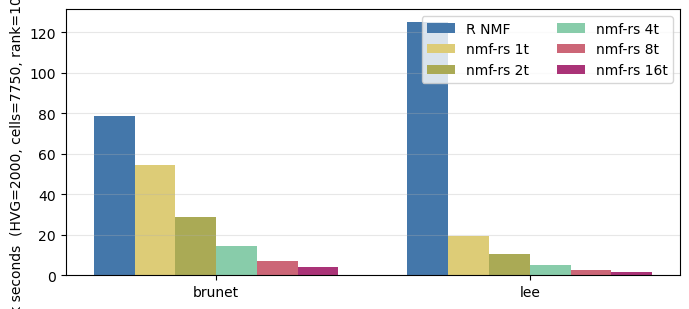

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(table)); width = 0.13
n_bars = 1 + len(THREADS)  # R + each thread count
colors = ['#4477aa', '#ddcc77', '#aaaa55', '#88ccaa', '#cc6677', '#aa3377']
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * width
ax.bar(x + offsets[0], table['R (s)'].values, width, label='R NMF', color=colors[0])
for k, nt in enumerate(THREADS):
    ax.bar(x + offsets[k+1], table[f'Rust {nt}t (s)'].values, width,
           label=f'nmf-rs {nt}t', color=colors[(k+1) % len(colors)])
ax.set_xticks(x); ax.set_xticklabels(table.index)
ax.set_ylabel(f'wall-clock seconds  (HVG={HVG_N}, cells={n_cells}, rank={RANK}, iters={MAXIT})')
ax.legend(loc='upper right', ncol=2); ax.grid(axis='y', alpha=0.3); fig.tight_layout()

## 7. Inspect the factors

Quick QC of the rank-10 brunet factorisation: top-loaded gene per
factor in `W` and the cell-type composition of the most-active cells
per factor in `H`.

In [9]:
W_rs = np.loadtxt(WORK/'brunet__W_rs.tsv')
H_rs = np.loadtxt(WORK/'brunet__H_rs.tsv')
gene_names = np.array(ad_hvg.var_names)
top = pd.DataFrame({f'factor {k}': gene_names[np.argsort(-W_rs[:, k])[:5]] for k in range(RANK)})
top

,factor 0,factor 1,factor 2,factor 3,factor 4,factor 5,factor 6,factor 7,factor 8,factor 9
0,FTL,S100A8,PPBP,MALAT1,CD74,MALAT1,FTL,CD74,MALAT1,NKG7
1,FTH1,S100A9,NRGN,CD74,HLA-DRA,NEAT1,FTH1,MALAT1,ACTB,MALAT1
2,ACTB,FTL,PF4,ACTB,HLA-DPA1,PLXDC2,S100A8,HLA-DRA,RPL3,ACTB
3,MALAT1,LYZ,CAVIN2,RPLP0,LYZ,ZEB2,S100A9,RPL3,RPLP0,GNLY
4,SAT1,ACTB,CCL5,FTH1,HLA-DPB1,SAT1,CRIP1,ACTB,LTB,CST7


In [10]:
ct_col = 'predicted_celltype' if 'predicted_celltype' in ad_hvg.obs.columns else 'cell_type'
comp = pd.DataFrame({
    f'factor {k}': ad_hvg.obs.iloc[np.argsort(-H_rs[k, :])[:50]][ct_col].value_counts().head(3)
    for k in range(RANK)
})
comp.fillna(0).astype(int)

,factor 0,factor 1,factor 2,factor 3,factor 4,factor 5,factor 6,factor 7,factor 8,factor 9
predicted_celltype,,,,,,,,,,
B cell,0,0,0,0,0,0,0,50,0,0
CD4+ T cell,0,0,0,0,0,0,0,0,50,0
CD14+ monocyte,0,50,0,0,1,49,50,0,0,0
CD16+ monocyte,50,0,0,0,0,1,0,0,0,0
Dendritic cell,0,0,0,0,37,0,0,0,0,0
Megakaryocyte,0,0,50,0,0,0,0,0,0,0
Natural killer cell,0,0,0,0,0,0,0,0,0,50
Plasmacytoid dendritic cell,0,0,0,50,0,0,0,0,0,0
Unassigned,0,0,0,0,12,0,0,0,0,0


## 8. Cleanup

In [11]:
shutil.rmtree(WORK, ignore_errors=True)